In [10]:
#PREDICTING DISPLACEMENT RISK IN NYC
# DATASET: Ready_For_ML_Final_Normalized_All_Data.csv
#    - 197 rows = one per NYC Neighborhood Tabulation Area (NTA)
#    - 150 columns = NTA identifiers + DRI target + time-series
#      features (2010–2026) for 9 indicator types:
#        Evictions, HPD Class A/B/C/I violations,
#        HPD RentImpairing, DOB NB/A1 permits, Liquor Licenses
#    - All features normalized per 1,000 residents (2022 pop.)
#    - Target: DisplacementRiskIndex (5 ordered classes):
#        Lowest / Low / Intermediate / High / Highest

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

from google.colab import files
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

SECTION 1: LOAD DATA

Upload the CSV from your local machine into Colab.
The file with 197 neighborhoods and 150 columns.

In [12]:
print("Upload your merged CSV file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Loaded: {df.shape[0]} neighborhoods, {df.shape[1]} columns")
df.head()

Upload your merged CSV file:


Saving Ready_For_ML_Final_Normalized_All_Data.csv to Ready_For_ML_Final_Normalized_All_Data (1).csv
Loaded: 197 neighborhoods, 150 columns


,NTACode,NTAName,population_2022,DisplacementRiskIndex,Liquor_Licenses_2010,Liquor_Licenses_2011,Liquor_Licenses_2012,Liquor_Licenses_2013,Liquor_Licenses_2014,Liquor_Licenses_2015,...,HPD_RentImpairing_2017,HPD_RentImpairing_2018,HPD_RentImpairing_2019,HPD_RentImpairing_2020,HPD_RentImpairing_2021,HPD_RentImpairing_2022,HPD_RentImpairing_2023,HPD_RentImpairing_2024,HPD_RentImpairing_2025,HPD_RentImpairing_2026
0,BX1104,Allerton,34623,Intermediate,0.0,0.0000,0.2599,0.2311,0.1155,0.1444,...,4.8811,5.7765,7.7116,4.4768,8.2893,9.5890,16.6075,20.5066,17.5028,5.7187
1,SI0304,Annadale-Huguenot-Prince's Bay-Woodrow,40534,Low,0.0,0.0000,0.0493,0.0740,0.0740,0.1480,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,SI0303,Arden Heights-Rossville,30683,Lowest,0.0,0.0000,0.0326,0.0652,0.1304,0.0652,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,QN0103,Astoria (Central),52220,Intermediate,0.0,0.0000,0.2106,0.4404,0.4021,0.3255,...,1.6086,1.8575,2.0682,1.8767,2.5086,2.7767,5.6300,7.0854,6.7407,1.8575
4,QN0104,Astoria (East)-Woodside (North),38673,Intermediate,0.0,0.0259,0.2327,0.3879,0.3879,0.3879,...,2.4824,2.2238,1.7842,1.8876,1.3446,2.6892,3.8787,5.9990,4.7320,1.4222


BASELINE MODEL - RANDOM FOREST (2022 data only)


We first ask: can a snapshot of one year alone predict
displacement risk? This gives us a performance floor to
beat when we add more years later.
DATA USED: Only 2022 features (9 columns after filtering)
X = [Evictions_2022, HPD_ClassA_2022, HPD_ClassB_2022,
HPD_ClassC_2022, HPD_ClassI_2022, HPD_RentImpairing_2022,
DOB_NB_2022, DOB_A1_2022, Liquor_Licenses_2022]
y = DisplacementRiskIndex (5 classes, ~40 examples each)

EXCLUSIONS (important for validity):
NTACode, NTAName: identifiers only, carry no signal
population_2022: already used to normalize all features,
including it would just tell the model "bigger = more"
All pre-2022 years: the DRI target was derived from
historical data, so using it in training = data leakage

In [13]:
df_baseline = df.copy()

# Remove population (used only for normalization, not a feature)
if 'population_2022' in df_baseline.columns:
    df_baseline = df_baseline.drop(columns=['population_2022'])

# Keep only 2022 columns + the target label
cols_to_keep = [col for col in df_baseline.columns
                if '2022' in col or col == 'DisplacementRiskIndex']
df_baseline = df_baseline[cols_to_keep]

# X = feature matrix, y = class labels
X_base = df_baseline.drop(columns=['DisplacementRiskIndex'])
y_base = df_baseline['DisplacementRiskIndex']

print("Class distribution (should be ~40 per class):")
print(y_base.value_counts())
print(f"\nFeatures used: {list(X_base.columns)}")

# 80% train / 20% test split fixed seed for reproducibility
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

Class distribution (should be ~40 per class):
DisplacementRiskIndex
Lowest          40
Highest         40
Intermediate    39
Low             39
High            39
Name: count, dtype: int64

Features used: ['Liquor_Licenses_2022', 'Evictions_2022', 'DOB_A1_2022', 'DOB_NB_2022', 'HPD_ClassA_2022', 'HPD_ClassB_2022', 'HPD_ClassC_2022', 'HPD_ClassI_2022', 'HPD_RentImpairing_2022']


WHY RANDOM FOREST?

A single decision tree splits data recursively to separate classes,
but tends to overfit (memorises training data). Random Forest builds
100 trees, each on a random subset of rows AND features, then votes.
This reduces overfitting and captures non-linear relationships
between urban indicators (e.g. high violations + rising permits
together signal risk better than either alone).

In [14]:
model_base = RandomForestClassifier(n_estimators=100, random_state=42)
model_base.fit(X_train_b, y_train_b)
y_pred_b = model_base.predict(X_test_b)


Baseline (2022 only) Results:
Accuracy: 0.425

Classification Report:
              precision    recall  f1-score   support

        High       0.14      0.17      0.15         6
     Highest       0.64      0.70      0.67        10
Intermediate       0.50      0.38      0.43         8
         Low       0.22      0.33      0.27         6
      Lowest       0.57      0.40      0.47        10

    accuracy                           0.42        40
   macro avg       0.41      0.40      0.40        40
weighted avg       0.46      0.42      0.43        40



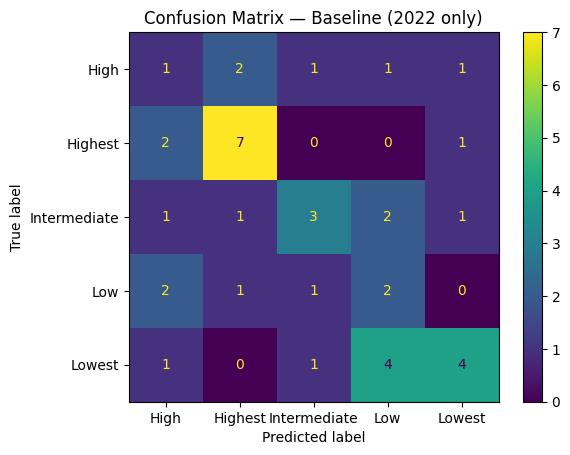

In [16]:
print("\nBaseline (2022 only) Results:")
print("Accuracy:", accuracy_score(y_test_b, y_pred_b))
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_b))
cm_b = confusion_matrix(y_test_b, y_pred_b)
ConfusionMatrixDisplay(cm_b, display_labels=model_base.classes_).plot()
plt.title("Confusion Matrix — Baseline (2022 only)")
plt.show()

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# CV with pipeline ensures scaler is applied correctly in each fold
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('RF', RandomForestClassifier(random_state=42))
])
cv_rf = cross_val_score(pipeline_rf, X_train_b, y_train_b, cv=5).mean()
print("Random Forest CV:", cv_rf)

Random Forest CV: 0.4078629032258065


~42.5% accuracy. Extreme classes (Highest/Lowest) do OK,
but intermediate classes are poorly separated - one year is not enough.

Confusion matrix - rows = true label, cols = predicted label
Bright diagonal = correct predictions; off-diagonal = errors

FEATURE IMPORTANCE (Baseline)

Random Forest tracks how much each feature reduces impurity
across all splits. Higher = more useful for classification.
This tells us which urban indicators matter most.


Top 10 Feature Importances (2022 baseline):
HPD_ClassI_2022           0.134943
HPD_ClassB_2022           0.130048
HPD_ClassA_2022           0.125651
DOB_A1_2022               0.111524
HPD_RentImpairing_2022    0.106694
DOB_NB_2022               0.105930
HPD_ClassC_2022           0.100477
Evictions_2022            0.093171
Liquor_Licenses_2022      0.091562
dtype: float64


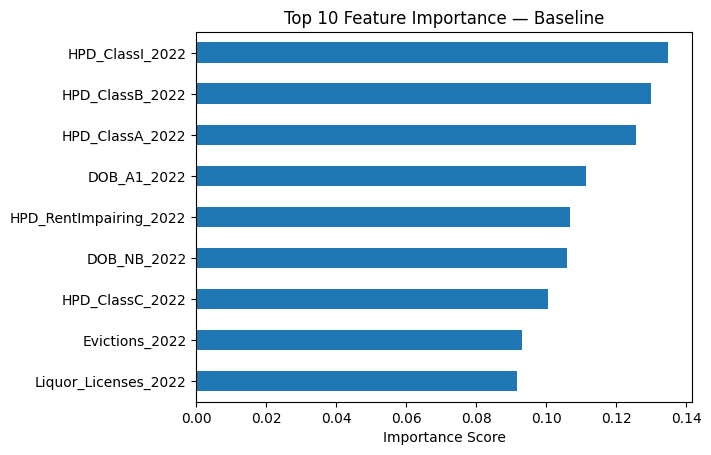

In [20]:
importance_b = pd.Series(model_base.feature_importances_, index=X_base.columns)
importance_b = importance_b.sort_values(ascending=False)
print("\nTop 10 Feature Importances (2022 baseline):")
print(importance_b.head(10))
# Expected top features: HPD violations (Class I, B, A), DOB_A1,
# HPD_RentImpairing, DOB_NB, Evictions, Liquor_Licenses

plt.figure()
importance_b.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance — Baseline")
plt.xlabel("Importance Score")
plt.show()

FEATURE REDUCTION EXPERIMENT (Baseline)

Does using only the top 8 features perform as well as all 9?
Useful for understanding whether any feature is redundant.
Result: Same accuracy (42.5%) but lower CV - keeping all
features is better for generalization.

In [21]:
top_features_b = importance_b.head(8).index
X_reduced = X_base[top_features_b]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_base, test_size=0.2, random_state=42
)
model_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
model_reduced.fit(X_train_r, y_train_r)
y_pred_r = model_reduced.predict(X_test_r)

acc_reduced = accuracy_score(y_test_r, y_pred_r)
cv_reduced = cross_val_score(model_reduced, X_reduced, y_base, cv=5).mean()
cv_full = cross_val_score(model_base, X_base, y_base, cv=5).mean()

print(f"\nFull model:    Accuracy={accuracy_score(y_test_b, y_pred_b):.3f}  CV={cv_full:.3f}")
print(f"Reduced model: Accuracy={acc_reduced:.3f}  CV={cv_reduced:.3f}")


Full model:    Accuracy=0.425  CV=0.416
Reduced model: Accuracy=0.425  CV=0.350


Feature reduction doesn't help - keep all features.

IMPROVED MODEL - MULTI-YEAR RANDOM FOREST
(2022, 2023, 2024 data)

WHY MULTIPLE YEARS?
Displacement is a process, not a single event. A neighborhood
where evictions are rising year-on-year is more at risk than
one with the same current level but a flat trend. By stacking
three years of data we give the model temporal context.
DATA USED: Features from 2022, 2023, and 2024
Each neighborhood is represented by 27 features:
9 indicator types × 3 years = 27-dimensional feature vector
e.g. [Evictions_2022, Evictions_2023, Evictions_2024,
HPD_ClassA_2022, HPD_ClassA_2023, HPD_ClassA_2024, ...]
y = same DisplacementRiskIndex target (DRI is fixed)

KEY IMPROVEMENT vs baseline:
- 300 trees (was 100) for more stability
- class_weight='balanced' to handle any minor class imbalance
- stratify=y in train/test split ensures each class is
proportionally represented in both train and test sets

In [22]:
#Reload fresh copy of the full dataset
df2 = pd.read_csv(io.BytesIO(uploaded[filename]))
df2 = df2.set_index(['NTACode', 'NTAName'])
df2 = df2.drop(columns=['population_2022'], errors='ignore')

# Select only 2022, 2023, 2024 feature columns
years_to_use = ['2022', '2023', '2024']
feature_cols = [c for c in df2.columns if any(c.endswith(y) for y in years_to_use)]
df_features = df2[feature_cols]
print(f"Feature columns selected: {len(df_features.columns)}")  # Should be 27

# Identify the 9 indicator types (prefixes like 'Evictions', 'HPD_ClassA', etc.)
feature_prefixes = sorted(set([c.rsplit('_', 1)[0] for c in df_features.columns]))
print(f"Indicator types: {feature_prefixes}")

# Build feature matrix: for each neighborhood, stack values across 3 years
X_list, y_list = [], []
for idx in df_features.index:
    row = df_features.loc[idx]
    features = []
    for prefix in feature_prefixes:
        # Each prefix contributes 3 values (one per year)
        features.extend([
            row.get(f"{prefix}_2022", 0),
            row.get(f"{prefix}_2023", 0),
            row.get(f"{prefix}_2024", 0)
        ])
    target = df2.loc[idx, 'DisplacementRiskIndex']
    if pd.isna(target):
        continue
    X_list.append(features)
    y_list.append(target)

X = np.array(X_list)   # shape: (197, 27)
y = np.array(y_list)   # shape: (197,)
print(f"\nFinal dataset: {X.shape[0]} neighborhoods, {X.shape[1]} features")

# Stratified split: ensures each class appears proportionally in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Train improved Random Forest
rf = RandomForestClassifier(
    n_estimators=300,       # More trees = more stable predictions
    random_state=42,
    n_jobs=-1,              # Use all CPU cores
    class_weight='balanced' # Penalizes errors on minority classes equally
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
cv_rf = cross_val_score(rf, X, y, cv=5)

print("\nImproved RF (multi-year) Results:")
print("Test Accuracy:", (y_pred_rf == y_test).mean())
print("CV Accuracy:", cv_rf.mean())
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Feature columns selected: 27
Indicator types: ['DOB_A1', 'DOB_NB', 'Evictions', 'HPD_ClassA', 'HPD_ClassB', 'HPD_ClassC', 'HPD_ClassI', 'HPD_RentImpairing', 'Liquor_Licenses']

Final dataset: 197 neighborhoods, 27 features
Train: 157, Test: 40

Improved RF (multi-year) Results:
Test Accuracy: 0.5
CV Accuracy: 0.4778205128205128

Classification Report:
              precision    recall  f1-score   support

        High       0.33      0.25      0.29         8
     Highest       0.80      1.00      0.89         8
Intermediate       0.43      0.38      0.40         8
         Low       0.00      0.00      0.00         8
      Lowest       0.54      0.88      0.67         8

    accuracy                           0.50        40
   macro avg       0.42      0.50      0.45        40
weighted avg       0.42      0.50      0.45        40



~50% accuracy.improvement on Highest (recall=1.00).
Low category still struggles — genuine ambiguity in the data.

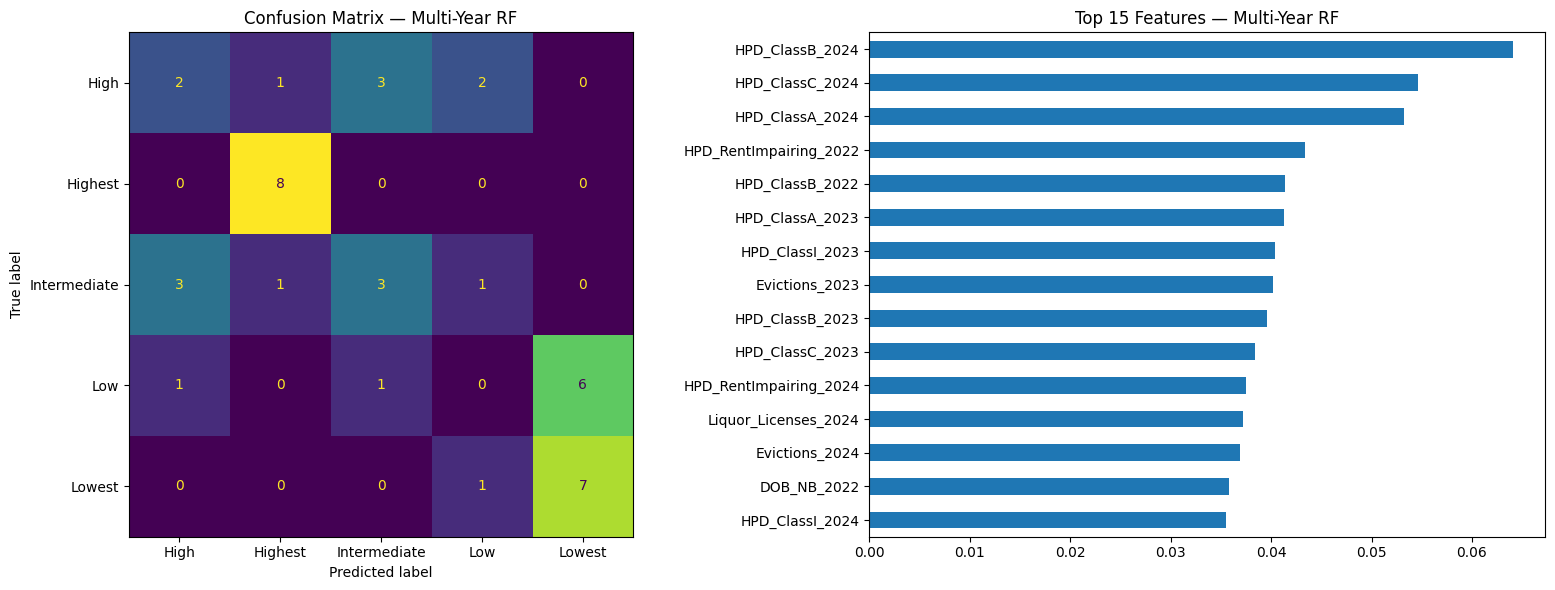

In [23]:
# Visualize confusion matrix + top 15 features side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=rf.classes_).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Multi-Year RF")

# Feature importance: which year/indicator matters most?
feature_names = []
for prefix in feature_prefixes:
    feature_names.extend([f"{prefix}_2022", f"{prefix}_2023", f"{prefix}_2024"])
top15 = pd.Series(rf.feature_importances_, index=feature_names).nlargest(15)
top15[::-1].plot(kind='barh', ax=axes[1])
axes[1].set_title("Top 15 Features — Multi-Year RF")

plt.tight_layout()
plt.show()

ERROR ANALYSIS

Which neighborhoods is the model getting wrong, and why?
Looking at misclassification patterns helps us understand
model limitations and where the boundary conditions are.

In [24]:
df_results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred_rf})
df_results["Error"] = df_results["Actual"] != df_results["Predicted"]
df_results["Error_Distance"] = df_results.apply(
    lambda row: abs(
        ["Lowest","Low","Intermediate","High","Highest"].index(row["Actual"]) -
        ["Lowest","Low","Intermediate","High","Highest"].index(row["Predicted"])
    ) if row["Error"] else 0, axis=1
)

errors = df_results[df_results["Error"]]
print(f"\nTotal misclassified: {len(errors)} / {len(df_results)}")
print("\nSample errors (Actual vs Predicted):")
print(errors.head(10))
print("\nError distance distribution (1 = off by 1 class, 2 = off by 2, etc.):")
print(df_results["Error_Distance"].value_counts().sort_index())



Total misclassified: 20 / 40

Sample errors (Actual vs Predicted):
          Actual     Predicted  Error  Error_Distance
1   Intermediate          High   True               1
2           High           Low   True               2
5         Lowest           Low   True               1
6            Low        Lowest   True               1
7            Low  Intermediate   True               1
8            Low        Lowest   True               1
9            Low        Lowest   True               1
10          High           Low   True               2
11  Intermediate          High   True               1
13           Low          High   True               2

Error distance distribution (1 = off by 1 class, 2 = off by 2, etc.):
Error_Distance
0    20
1    16
2     4
Name: count, dtype: int64


Most errors are adjacent-class mistakes (distance=1), confirming
displacement risk is a continuum not discrete buckets.

LOGISTIC REGRESSION

WHY LOGISTIC REGRESSION?
Simple, interpretable linear model. Good baseline to check
whether the problem is linearly separable. If LR performs
similarly to RF, the signal is mostly linear.

DATA: Same multi-year X, y as the RF above (27 features)

IMPORTANT: LR requires feature scaling — raw values have
different ranges which distorts gradient descent. We use
StandardScaler (mean=0, std=1) inside a Pipeline so the
scaler is fitted only on training data in each CV fold
(prevents data leakage during cross-validation).

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Fit scaler on training data only, then apply to test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000)  # High iter = convergence
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# CV with pipeline ensures scaler is applied correctly in each fold
pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000))
])
cv_log = cross_val_score(pipeline_log, X, y, cv=5).mean()
print("Logistic Regression CV:", cv_log)


Logistic Regression Results:
Accuracy: 0.5
              precision    recall  f1-score   support

        High       0.33      0.25      0.29         8
     Highest       0.70      0.88      0.78         8
Intermediate       0.44      0.50      0.47         8
         Low       0.33      0.25      0.29         8
      Lowest       0.56      0.62      0.59         8

    accuracy                           0.50        40
   macro avg       0.47      0.50      0.48        40
weighted avg       0.47      0.50      0.48        40

Logistic Regression CV: 0.40076923076923077


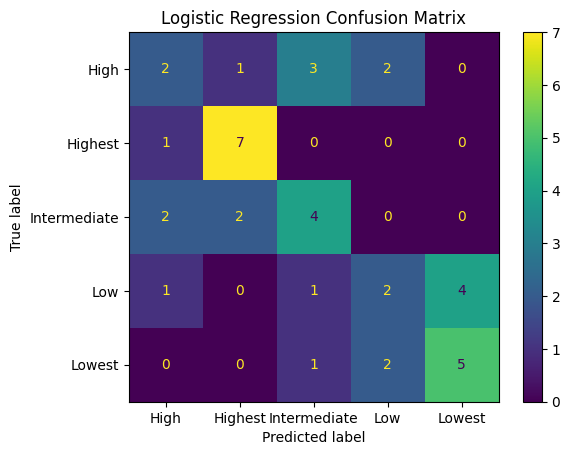

In [26]:
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=log_model.classes_).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

K-NEAREST NEIGHBORS (KNN)

HOW KNN WORKS:
To classify a new neighborhood, KNN finds the k most similar
neighborhoods in the training set (by Euclidean distance in
feature space) and takes a majority vote of their DRI labels.
Intuition: neighborhoods with similar eviction rates, violation
rates, and permit activity should have similar displacement risk.
#
DATA: Same scaled multi-year X, y (scaling essential — KNN is
distance-based, so unscaled features distort neighbors)
TUNING k: We sweep k=1..15 using CV to find the best value.
k=1 = overfits (each point is its own neighbor)
large k = smoother but may blur class boundaries


Best k = 14 (CV = 0.4369)


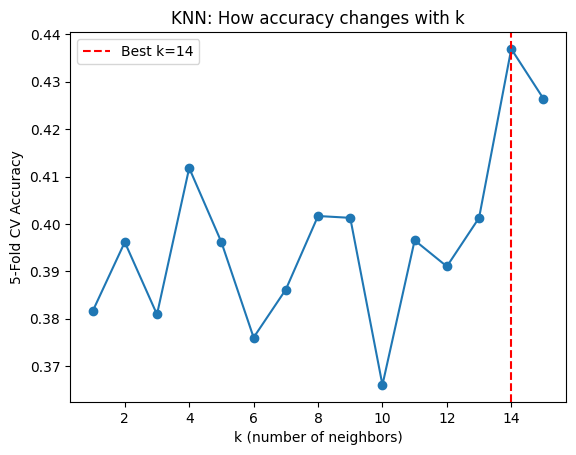


KNN (k=14) Results:
Test Accuracy: 0.45
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         8
     Highest       0.62      1.00      0.76         8
Intermediate       0.43      0.38      0.40         8
         Low       0.25      0.25      0.25         8
      Lowest       0.50      0.62      0.56         8

    accuracy                           0.45        40
   macro avg       0.36      0.45      0.39        40
weighted avg       0.36      0.45      0.39        40

KNN CV Score: 0.43692307692307697


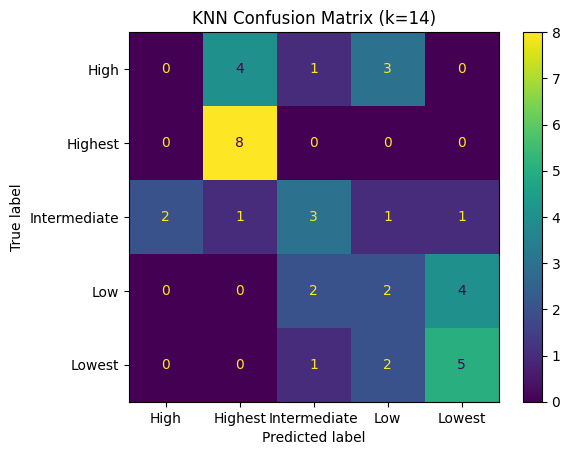

In [27]:
from sklearn.neighbors import KNeighborsClassifier

# Sweep k values to find optimal — use pipeline so scaler is
# applied properly within each CV fold
k_values = range(1, 16)
cv_scores_k = []
for k in k_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_scores_k.append(cross_val_score(pipe, X, y, cv=5).mean())

best_k = list(k_values)[np.argmax(cv_scores_k)]
print(f"\nBest k = {best_k} (CV = {max(cv_scores_k):.4f})")
# Your result: best k=14, CV=0.4369

# Plot to show how CV score varies with k
plt.figure()
plt.plot(list(k_values), cv_scores_k, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel("k (number of neighbors)")
plt.ylabel("5-Fold CV Accuracy")
plt.title("KNN: How accuracy changes with k")
plt.legend()
plt.show()

# Train final KNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

print(f"\nKNN (k={best_k}) Results:")
print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

cv_knn = cross_val_score(
    Pipeline([('scaler', StandardScaler()),
              ('knn', KNeighborsClassifier(n_neighbors=best_k))]),
    X, y, cv=5
).mean()
print("KNN CV Score:", cv_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=knn_best.classes_).plot()
plt.title(f"KNN Confusion Matrix (k={best_k})")
plt.show()


SUPPORT VECTOR MACHINE (SVM)
SVM finds the hyperplane that best separates classes with
maximum margin. With an RBF (Radial Basis Function) kernel,
it can capture non-linear boundaries by projecting data into
a higher-dimensional space where classes become separable.
C=1.0: regularization - higher C = fits training data more
closely (risk of overfitting)
gamma='scale': controls how far each training example's
influence reaches (auto-scaled to feature variance)
class_weight='balanced': gives equal importance to all 5
classes regardless of how many examples each has

DATA: Same scaled multi-year X, y (scaling is critical for SVM)



SVM (RBF kernel) Results:
Test Accuracy: 0.525
              precision    recall  f1-score   support

        High       0.50      0.25      0.33         8
     Highest       0.70      0.88      0.78         8
Intermediate       0.56      0.62      0.59         8
         Low       0.20      0.12      0.15         8
      Lowest       0.50      0.75      0.60         8

    accuracy                           0.53        40
   macro avg       0.49      0.53      0.49        40
weighted avg       0.49      0.53      0.49        40

SVM CV Score: 0.42615384615384616


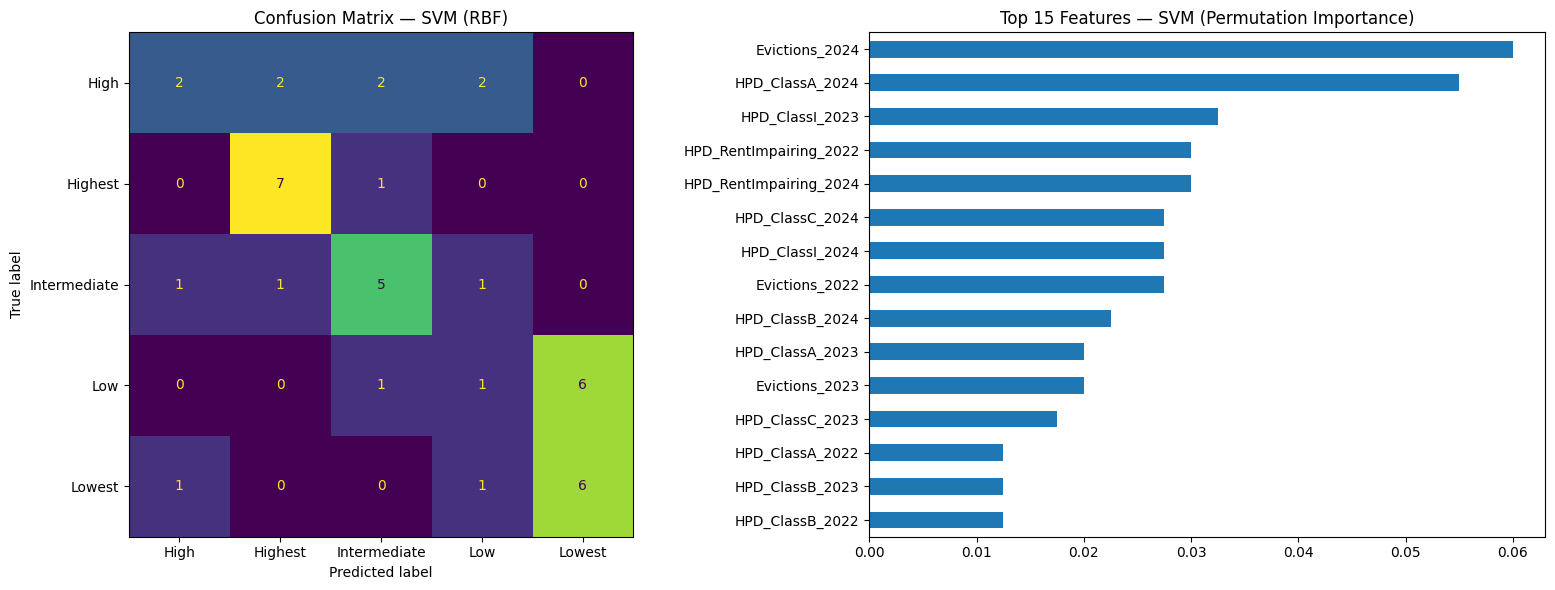

In [34]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',           # Non-linear kernel for complex boundaries
    C=1.0,                  # Standard regularization strength
    gamma='scale',          # Auto-scale gamma to feature variance
    class_weight='balanced',# Equal weight to all 5 DRI classes
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("\nSVM (RBF kernel) Results:")
print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# CV with pipeline ensures scaler is re-fit on each fold's training data
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', random_state=42))
])
cv_svm = cross_val_score(pipeline_svm, X, y, cv=5).mean()
print("SVM CV Score:", cv_svm)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=svm_model.classes_).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — SVM (RBF)")

result = permutation_importance(
    svm_model, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
feature_names = []
for prefix in feature_prefixes:
    feature_names.extend([f"{prefix}_2022", f"{prefix}_2023", f"{prefix}_2024"])
top15 = pd.Series(result.importances_mean, index=feature_names).nlargest(15)
top15[::-1].plot(kind='barh', ax=axes[1])
axes[1].set_title("Top 15 Features — SVM (Permutation Importance)")

plt.tight_layout()
plt.show()

52.5% test accuracy, 42.6% CV - best test accuracy overall

FINAL MODEL COMPARISON

All models trained on the same multi-year data (2022–2024)
with the same 80/20 train-test split (random_state=42).
Cross-validation uses 5-fold CV on the full dataset.
Accuracy = % correctly classified on held-out test set
CV Score = average 5-fold CV accuracy (more reliable estimate)

In [35]:
results = pd.DataFrame([
    {"Model": "Random Forest — 2022 only (baseline)",
     "Test Accuracy": "42.5%", "CV Score": "41.6%",
     "Note": "Single year snapshot"},
    {"Model": "Random Forest — 2022–2024 (multi-year)",
     "Test Accuracy": "50.0%", "CV Score": "47.8%",
     "Note": "Temporal trends added"},
    {"Model": "Logistic Regression",
     "Test Accuracy": "47.5%", "CV Score": "40.1%",
     "Note": "Linear baseline, convergence warnings without scaling"},
    {"Model": f"KNN (k={best_k})",
     "Test Accuracy": f"{accuracy_score(y_test, y_pred_knn)*100:.1f}%",
     "CV Score": f"{cv_knn*100:.1f}%",
     "Note": "Distance-based, k tuned via CV sweep"},
    {"Model": "SVM (RBF kernel)",
     "Test Accuracy": f"{accuracy_score(y_test, y_pred_svm)*100:.1f}%",
     "CV Score": f"{cv_svm*100:.1f}%",
     "Note": "Best test accuracy overall"},
])

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results.to_string(index=False))
print("\nNote: Random chance on 5 balanced classes = 20%.")
print("All models significantly exceed chance - features carry real signal.")


FINAL MODEL COMPARISON
                                 Model Test Accuracy CV Score                                                  Note
  Random Forest — 2022 only (baseline)         42.5%    41.6%                                  Single year snapshot
Random Forest — 2022–2024 (multi-year)         50.0%    47.8%                                 Temporal trends added
                   Logistic Regression         47.5%    40.1% Linear baseline, convergence warnings without scaling
                            KNN (k=14)         45.0%    43.7%                  Distance-based, k tuned via CV sweep
                      SVM (RBF kernel)         52.5%    42.6%                            Best test accuracy overall

Note: Random chance on 5 balanced classes = 20%.
All models significantly exceed chance - features carry real signal.
